# Clustering Tutorial: K-Means and DBSCAN

**Instructor: Dr. Arun B Ayyar**

**Date:** 17.02.2025 AN

---

This notebook contains practical exercises on K-Means and DBSCAN clustering algorithms with diverse datasets.

Each problem includes:
- **Problem statement** with dataset description
- **Hints** including scikit-learn functions to use
- **Complete solution** with code and visualizations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_blobs, make_moons, make_circles, load_iris, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## Problem 1: Iris Dataset (4D → 2D with PCA)

**Dataset:** Iris flower measurements (150 samples, 4 features)

**Tasks:**
**Note:** Data is already generated for you. Focus on:
1. Standardize the features
2. Use the elbow method to find optimal k (test k=2 to 10)
3. Apply K-Means with optimal k
4. Reduce to 2D using PCA for visualization
5. Visualize clusters and calculate silhouette score

**Hints:**
- Use `load_iris()` from sklearn.datasets
- Use `StandardScaler()` for standardization
- Use `KMeans(n_clusters=k, random_state=42)` for clustering
- Plot inertia (WCSS) vs k for elbow method
- Use `PCA(n_components=2)` for dimensionality reduction
- Use `silhouette_score()` to evaluate clustering quality

In [3]:
# Load and prepare data
iris = load_iris()
X_iris = iris.data
y_true = iris.target




[222.36170496502302, 139.82049635974982, 114.09254690403091, 90.92751382392049, 81.54439095511785, 72.63114382667189, 62.54060569578125, 55.119492805290605, 47.3910351763471]
[0.5817500491982808, 0.45994823920518635, 0.38694104154427816, 0.3459012795948778, 0.31707940193569023, 0.3201967939183684, 0.33869173894897225, 0.3423598384813203, 0.3517926760640288]


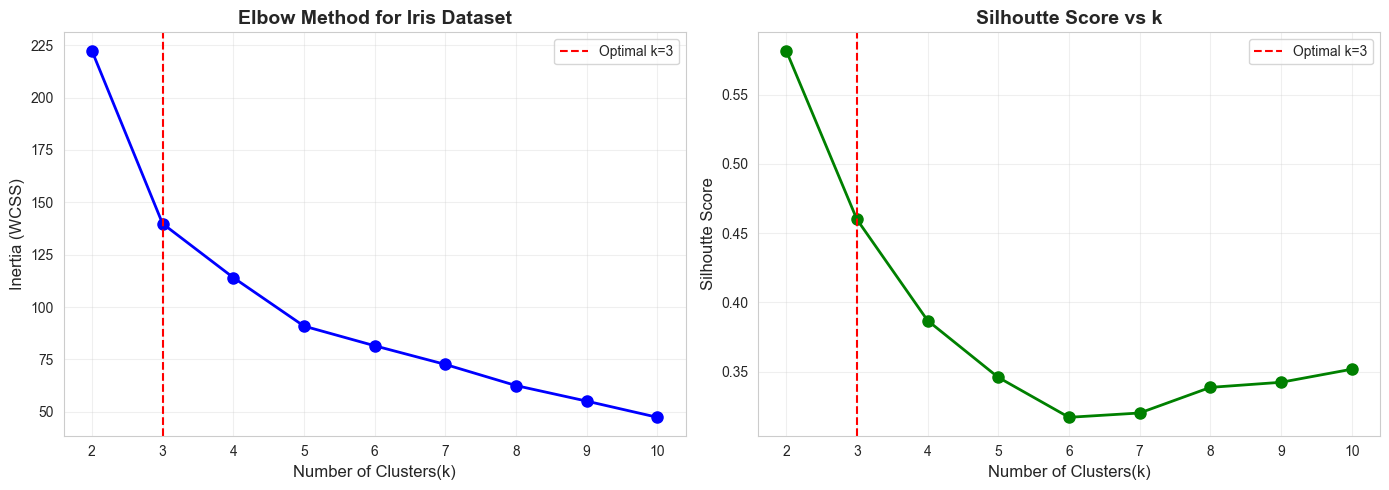

In [4]:
# Standardize
# Your code here
# Apply clustering algorithm and visualize results
sclaer = StandardScaler()
X_iris_scaled = sclaer.fit_transform(X_iris)

inertias = []
silhouette_scores = []
K_range = range(2,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_iris_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_iris_scaled, kmeans.labels_))

print(inertias)
print(silhouette_scores)  

fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters(k)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method for Iris Dataset', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=3, color='r', linestyle='--', label='Optimal k=3')
axes[0].legend()

axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters(k)', fontsize=12)
axes[1].set_ylabel('Silhoutte Score', fontsize=12)
axes[1].set_title('Silhoutte Score vs k', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=3, color='r', linestyle='--', label='Optimal k=3')
axes[1].legend()

plt.tight_layout()
plt.show()

## Problem 2: Customer Segmentation (Synthetic Data)

**Dataset:** Customer data with Annual Income and Spending Score (200 samples)

**Tasks:**
**Note:** Data is already generated for you. Focus on:
1. Use elbow method to find optimal k
2. Apply K-Means clustering
3. Visualize and interpret customer segments
4. Provide business insights for each segment

**Hints:**
- Use `make_blobs(n_samples=200, n_features=2, centers=5, cluster_std=1.0, random_state=42)`
- Features represent: [Annual Income (k$), Spending Score (1-100)]
- Use `KMeans(n_clusters=k, random_state=42)`
- Calculate cluster statistics (mean income, mean spending) for each segment

In [6]:
# Generate customer data
X_customers, _ = make_blobs(n_samples=200, n_features=2, centers=5, cluster_std=1.0, random_state=42)

# Scale to realistic ranges
X_customers[:, 0] = X_customers[:, 0] * 10 + 50  # Annual Income: 30-70k
X_customers[:, 1] = X_customers[:, 1] * 10 + 50  # Spending Score: 30-70


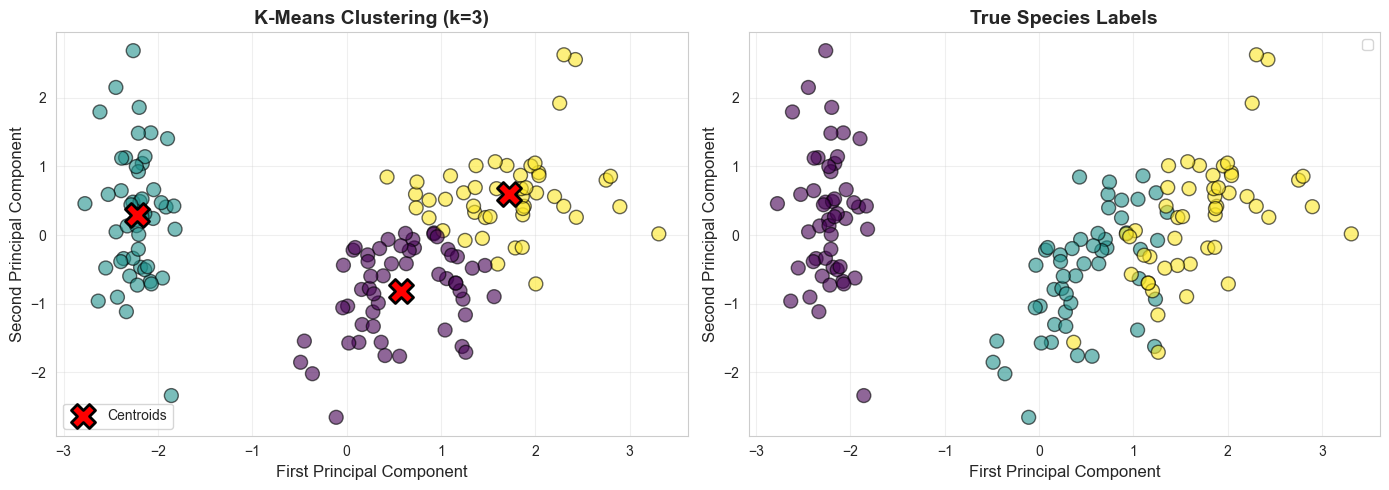


Silhoutte Score: 0.460

Daviews-Boulding Index: 0.834


In [7]:
# Your code here
# Apply clustering algorithm and visualize results
kmeans_iris = KMeans(n_clusters=3, random_state=42, n_init=10)
label_iris = kmeans_iris.fit_predict(X_iris_scaled)

pca = PCA(n_components=2)
X_iris_2d = pca.fit_transform(X_iris_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

scatter1 = axes[0].scatter(X_iris_2d[:,0], X_iris_2d[:, 1], c=label_iris, cmap='viridis', s=100, alpha=0.6, edgecolors='k')
axes[0].scatter(pca.transform(kmeans_iris.cluster_centers_)[:,0],
                pca.transform(kmeans_iris.cluster_centers_)[:,1],
                c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroids')
axes[0].set_xlabel('First Principal Component', fontsize=12)
axes[0].set_ylabel('Second Principal Component', fontsize=12)
axes[0].set_title('K-Means Clustering (k=3)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

scatter2 = axes[1].scatter(X_iris_2d[:,0], X_iris_2d[:, 1], c=y_true, cmap='viridis', s=100, alpha=0.6, edgecolors='k')
axes[1].set_xlabel('First Principal Component', fontsize=12)
axes[1].set_ylabel('Second Principal Component', fontsize=12)
axes[1].set_title('True Species Labels', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nSilhoutte Score: {silhouette_score(X_iris_scaled, label_iris):.3f}")
print(f"\nDaviews-Boulding Index: {davies_bouldin_score(X_iris_scaled, label_iris):.3f}")

## Problem 3: Anisotropic Blobs (Stretched Clusters)

**Dataset:** 3 clusters with different shapes and orientations (300 samples)

**Tasks:**
**Note:** Data is already generated for you. Focus on:
1. Apply K-Means with k=3
2. Visualize the results
3. Analyze why K-Means struggles with this data

**Hints:**
- Use `make_blobs()` with `cluster_std=[1.0, 2.5, 0.5]` for different cluster spreads
- Apply transformation matrix to create anisotropy
- Use `KMeans(n_clusters=3, random_state=42)`
- Compare cluster assignments with true labels
- Note: K-Means assumes spherical clusters!

In [14]:
# Generate anisotropic data
X_aniso, y_aniso = make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=[1.0, 2.5, 0.5], random_state=42)


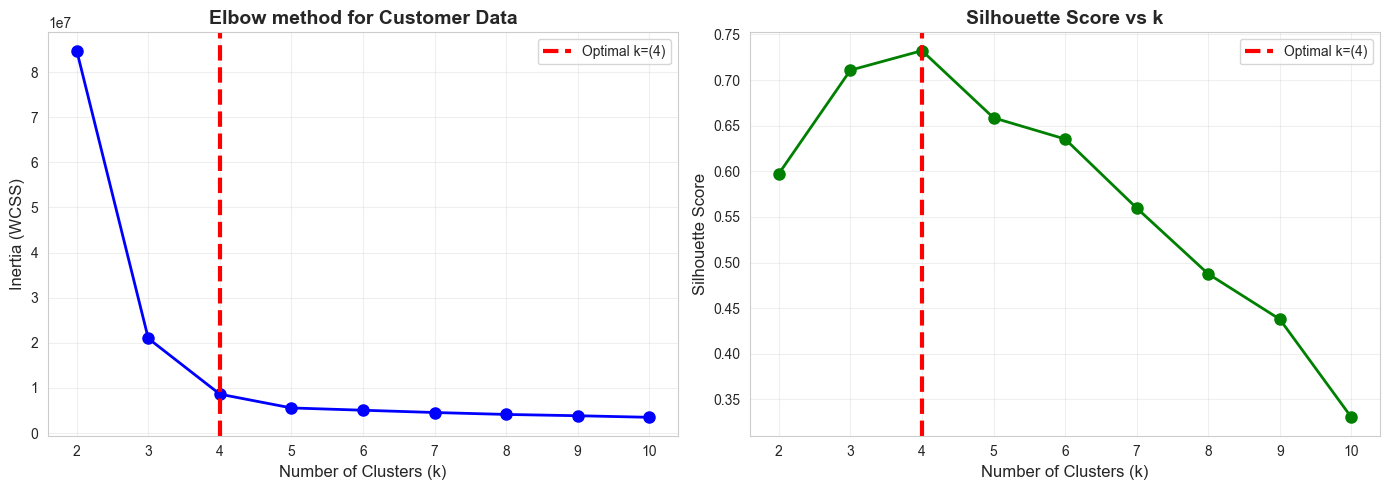

In [15]:
# Generate anisotropic data
#X_customers, y_aniso = make_blobs(n_samples=300, n_features=2, centers=5, cluster_std=1.0, random_state=42)

# Your code here
# Apply clustering algorithm and visualize results
X_customers[:,0] = X_customers[:,0] * 10 + 50
X_customers[:,1] = X_customers[:,1] * 10 + 50

inertias = []
silhouette_scores = []
K_range = range(2,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    inertias.append(kmeans.fit(X_customers).inertia_)
    silhouette_scores.append(silhouette_score(X_customers, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow method for Customer Data', fontsize=14, fontweight='bold')
axes[0].axvline(x=4, color='r', linestyle='--', linewidth=3, label='Optimal k=(4)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score vs k', fontsize=14, fontweight='bold')
axes[1].axvline(x=4, color='r', linestyle='--', linewidth=3, label='Optimal k=(4)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

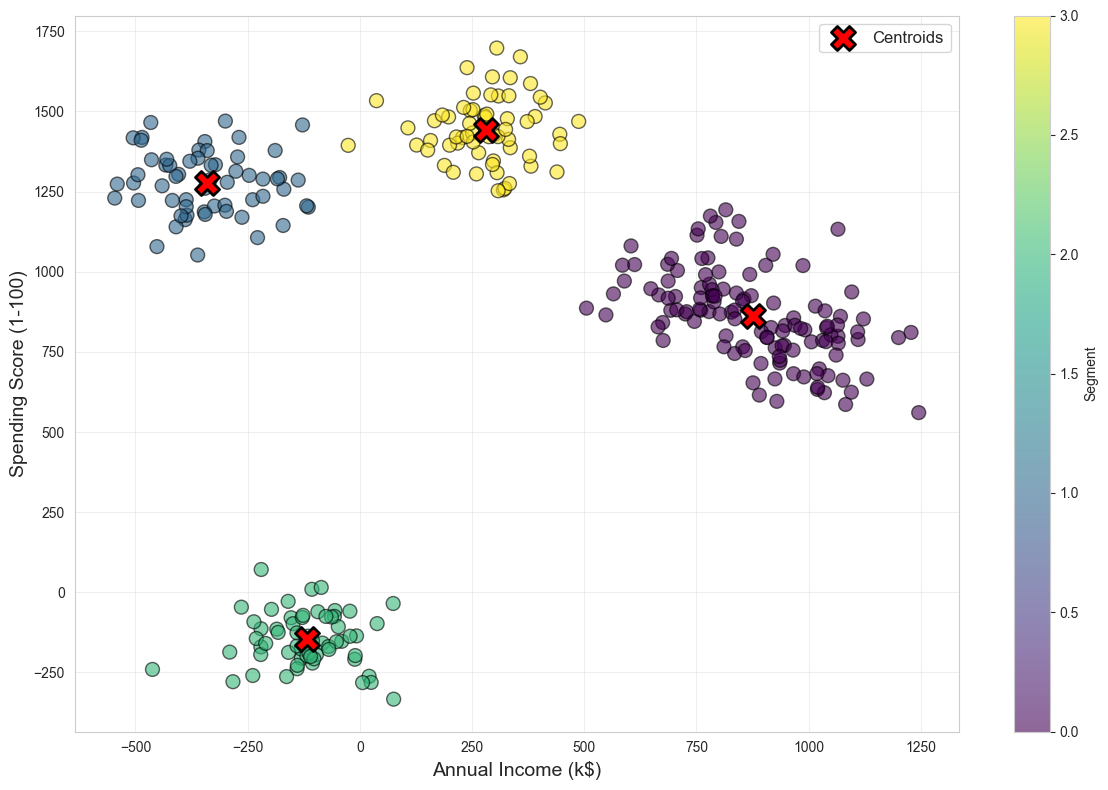

In [16]:
kmeans_customers = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_customers = kmeans_customers.fit_predict(X_customers)

plt.figure(figsize=(12,8))

scatter = plt.scatter(X_customers[:,0], X_customers[:,1], c=labels_customers, cmap='viridis', s=100, alpha=0.6, edgecolors='k')
plt.scatter(kmeans_customers.cluster_centers_[:,0], kmeans_customers.cluster_centers_[:,1], color='r', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroids')
plt.xlabel('Annual Income (k$)', fontsize=14)
plt.ylabel('Spending Score (1-100)', fontsize=14)
plt.legend(fontsize=12)
plt.colorbar(scatter, label='Segment')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Problem 4: Concentric Circles (Non-Convex Clusters)

**Dataset:** Two concentric circles (400 samples)

**Tasks:**
**Note:** Data is already generated for you. Focus on:
1. Apply K-Means with k=2
2. Visualize and analyze the failure
3. Explain why K-Means fails on this data

**Hints:**
- Use `make_circles(n_samples=400, factor=0.5, noise=0.05, random_state=42)`
- Use `KMeans(n_clusters=2, random_state=42)`
- K-Means cannot handle non-convex shapes!
- This is where DBSCAN or Spectral Clustering excel

In [17]:
# Generate concentric circles
X_circles, y_circles = make_circles(n_samples=400, factor=0.5, noise=0.05, random_state=42)


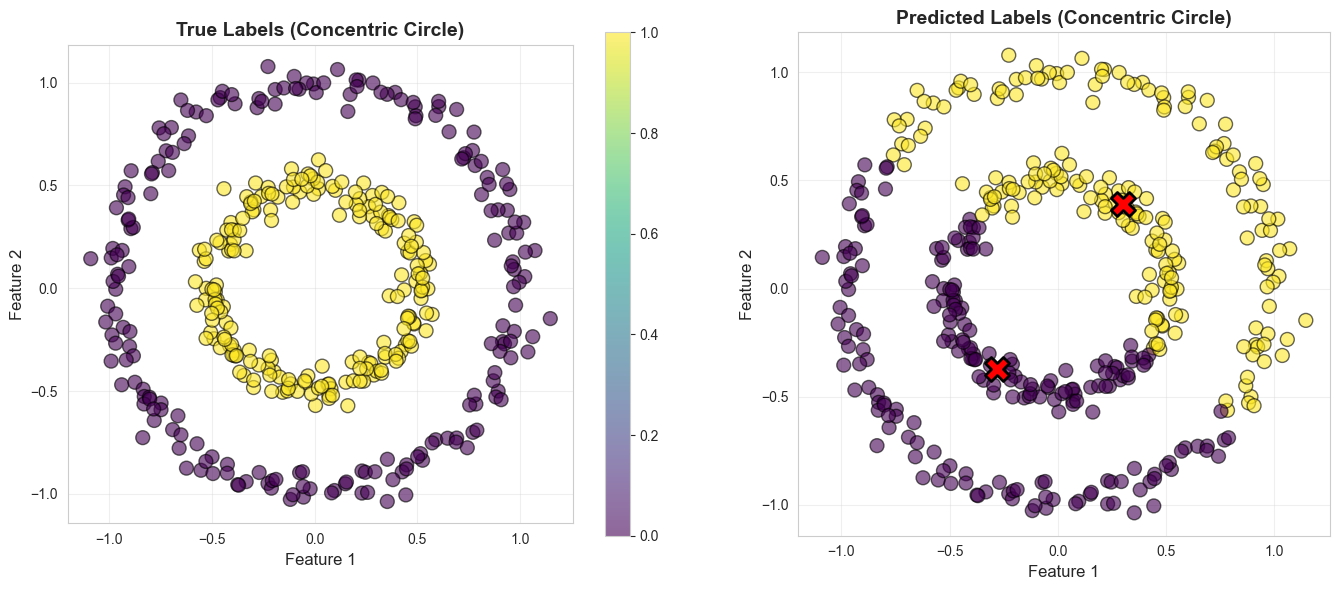

In [21]:
# Your code here
# Apply clustering algorithm and visualize results
kmeans_circles = KMeans(n_clusters=2, random_state=42, n_init=10)
y_circles_predicted = kmeans_circles.fit_predict(X_circles)

fig, axes = plt.subplots(1,2, figsize=(14, 6))

scatter1 = axes[0].scatter(X_circles[:,0], X_circles[:,1], c=y_circles, cmap='viridis', s=100, alpha=0.6, edgecolors='k')
axes[0].set_xlabel('Feature 1', fontsize=12)
axes[0].set_ylabel('Feature 2', fontsize=12)
axes[0].set_title('True Labels (Concentric Circle)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')
plt.colorbar(scatter1, ax=axes[0])

scatter2 = axes[1].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles_predicted, cmap='viridis', s=100, alpha=0.6, edgecolors='k')
axes[1].scatter(kmeans_circles.cluster_centers_[:,0], kmeans_circles.cluster_centers_[:,1], c='red', marker='X', s=300, 
                edgecolors='black', linewidth=2, label='Centroids')
axes[1].set_xlabel('Feature 1', fontsize=12)
axes[1].set_ylabel('Feature 2', fontsize=12)
axes[1].set_title('Predicted Labels (Concentric Circle)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

## Problem 5: Crescent Moons (Non-Convex Shapes)

**Dataset:** Two interleaving crescent moons (300 samples)

**Tasks:**
**Note:** Data is already generated for you. Focus on:
1. Apply both K-Means and DBSCAN
2. Compare their performance
3. Tune DBSCAN parameters (eps and min_samples)

**Hints:**
- Use `make_moons(n_samples=300, noise=0.05, random_state=42)`
- For K-Means: `KMeans(n_clusters=2, random_state=42)`
- For DBSCAN: `DBSCAN(eps=0.2, min_samples=5)`
- Try different eps values: [0.1, 0.2, 0.3]
- Noise points in DBSCAN are labeled as -1

In [22]:
# Generate moons data
X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)


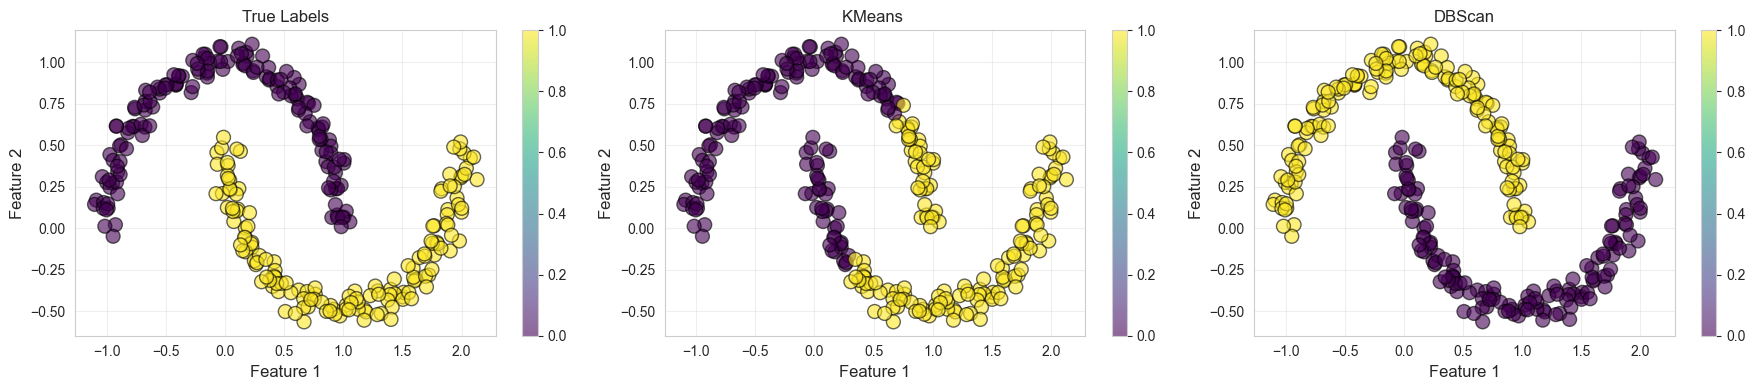

In [23]:
# Your code here
# Apply clustering algorithm and visualize results
kmeans_moons = KMeans(n_clusters=2, random_state=42, n_init=10)
y_moons_kmeans_predicted = kmeans_moons.fit_predict(X_moons)

dbscan_moons = DBSCAN(eps=0.2, min_samples=5)
y_moons_dbscan_predicted = dbscan_moons.fit_predict(X_moons)

fig, axes = plt.subplots(1,3, figsize=(18,4))

scatter1 = axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', s=100, alpha=0.6, edgecolors='k')
axes[0].set_xlabel('Feature 1', fontsize=12)
axes[0].set_ylabel('Feature 2', fontsize=12)
axes[0].set_title('True Labels')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0])

scatter2 = axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons_kmeans_predicted, cmap='viridis', s=100, alpha=0.6, edgecolors='k')
axes[1].set_xlabel('Feature 1', fontsize=12)
axes[1].set_ylabel('Feature 2', fontsize=12)
axes[1].set_title('KMeans ')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1])

scatter3 = axes[2].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons_dbscan_predicted, cmap='viridis', s=100, alpha=0.6, edgecolors='k')
axes[2].set_xlabel('Feature 1', fontsize=12)
axes[2].set_ylabel('Feature 2', fontsize=12)
axes[2].set_title('DBScan')
axes[2].grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=axes[2])

plt.tight_layout()
plt.show()

## Problem 6: Concentric Circles with DBSCAN

**Dataset:** Two concentric circles (same as Problem 4)

**Tasks:**
**Note:** Data is already generated for you. Focus on:
1. Use the concentric circles data
1. Apply DBSCAN with appropriate parameters
2. Compare with K-Means results
3. Experiment with different eps values

**Hints:**
- Use `make_circles(n_samples=400, factor=0.5, noise=0.05, random_state=42)`
- Try `DBSCAN(eps=0.15, min_samples=5)`
- Visualize how eps affects clustering
- DBSCAN should separate inner and outer circles correctly

In [24]:
# We already have X_circles and y_circles from Problem 4

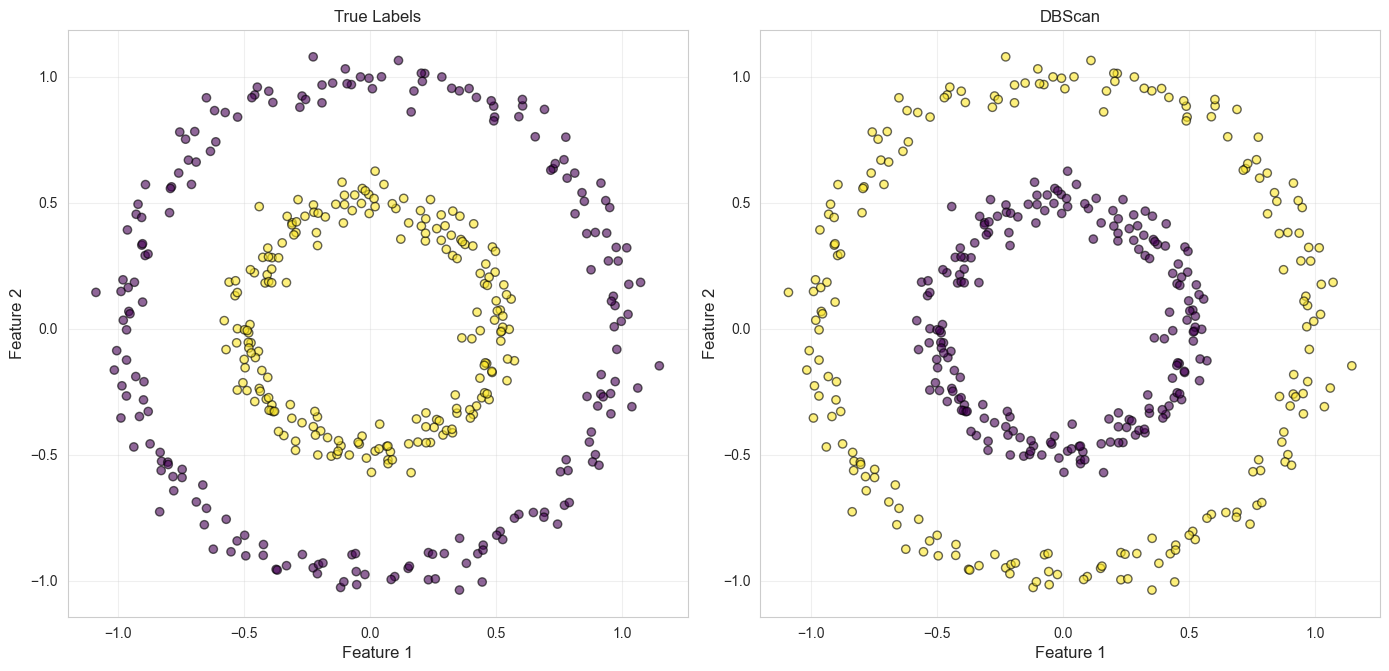

In [28]:
# Your code here
# Apply clustering algorithm and visualize results
dbscan_circles = DBSCAN(eps=0.15, min_samples=5)
y_circles_dbscan_predicted = dbscan_circles.fit_predict(X_circles)

fig, axes = plt.subplots(1,2, figsize=(14,8))

axes[0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='viridis', alpha=0.6, edgecolors='k')
axes[0].set_xlabel('Feature 1', fontsize=12)
axes[0].set_ylabel('Feature 2', fontsize=12)
axes[0].set_title('True Labels')
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

axes[1].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles_dbscan_predicted, cmap='viridis', alpha=0.6, edgecolors='k')
axes[1].set_xlabel('Feature 1', fontsize=12)
axes[1].set_ylabel('Feature 2', fontsize=12)
axes[1].set_title('DBScan')
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

## Problem 7: Clusters with Varied Density

**Dataset:** 3 clusters with different densities (400 samples)

**Tasks:**
**Note:** Data is already generated for you. Focus on:
1. Apply K-Means and DBSCAN
2. Compare their ability to handle density variations
3. Analyze the trade-offs

**Hints:**
- Use `make_blobs()` with `cluster_std=[0.5, 1.5, 3.0]` for different densities
- K-Means: `KMeans(n_clusters=3, random_state=42)`
- DBSCAN: `DBSCAN(eps=0.5, min_samples=5)`
- DBSCAN may struggle with varied densities (single eps for all clusters)

In [35]:
# Generate varied density data
X_varied, y_varied = make_blobs(n_samples=[100, 150, 150], n_features=2, cluster_std=[0.5, 1.5, 3.0], random_state=42)


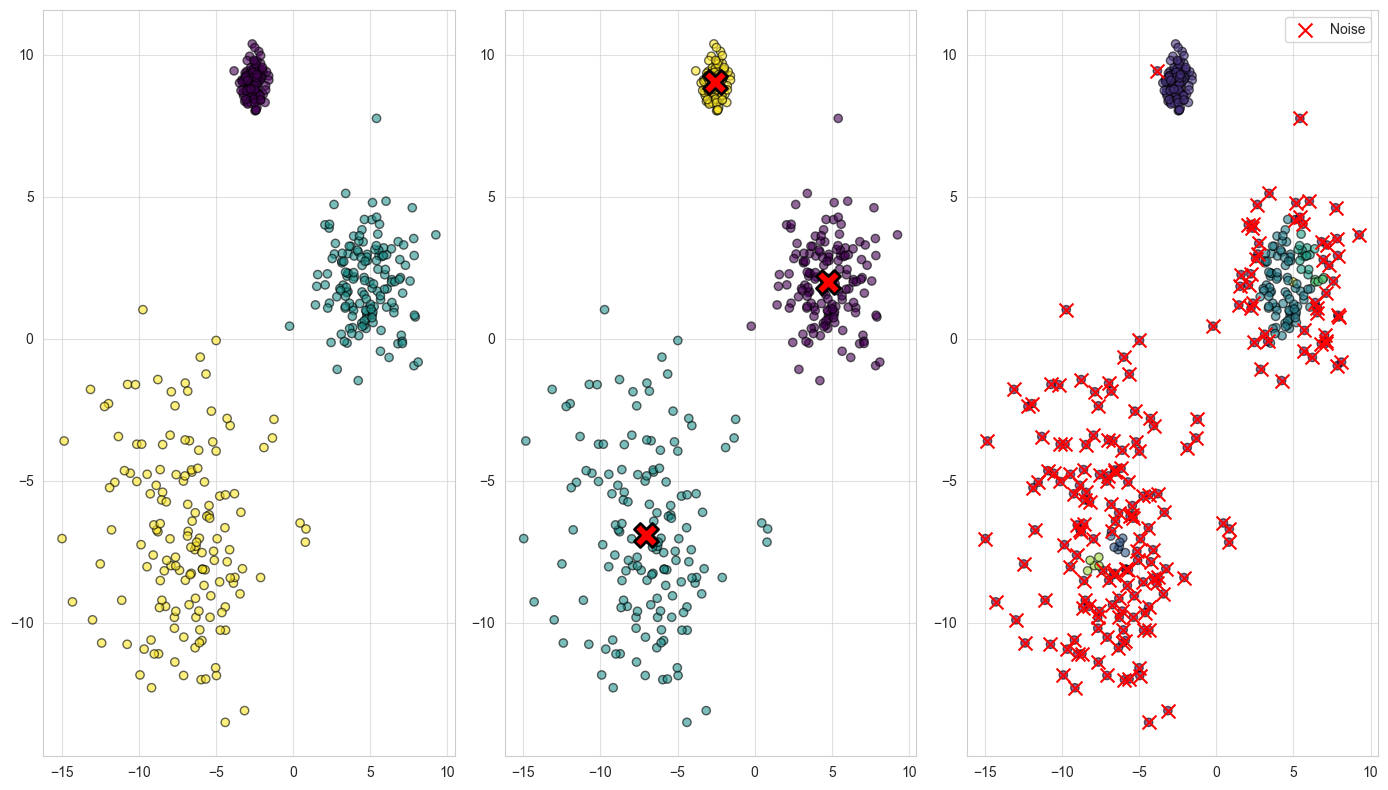

K-means Silhoutte Score: 0.742
DBSCAN Silhoutte Score: 0.449


In [47]:
# Your code here
# Apply clustering algorithm and visualize results
kmeans_varied = KMeans(n_clusters=3, random_state=42, n_init=10)
y_varied_kmeans_predicted = kmeans_varied.fit_predict(X_varied)

dbscan_varied = DBSCAN(eps=0.5, min_samples=5)
y_varied_dbscan_predicted = dbscan_varied.fit_predict(X_varied)
noise_mask = y_varied_dbscan_predicted == -1

fig, axes = plt.subplots(1,3, figsize=(14,8))

axes[0].scatter(X_varied[:, 0], X_varied[:, 1], c=y_varied, cmap='viridis', alpha=0.6, edgecolors='k')
axes[0].grid(True, alpha=0.6)

axes[1].scatter(X_varied[:, 0], X_varied[:, 1], c=y_varied_kmeans_predicted, cmap='viridis', alpha=0.6, edgecolors='k')
axes[1].scatter(kmeans_varied.cluster_centers_[:,0], kmeans_varied.cluster_centers_[:,1], cmap='viridis', s=300, marker='X', color='red', edgecolors='black', linewidth=2)
axes[1].grid(True, alpha=0.6)

axes[2].scatter(X_varied[:, 0], X_varied[:, 1], c=y_varied_dbscan_predicted, cmap='viridis', alpha=0.6, edgecolors='k')
axes[2].scatter(X_varied[noise_mask, 0], X_varied[noise_mask, 1], c='red', marker='x', s=100, label='Noise')
axes[2].grid(True, alpha=0.6)
axes[2].legend()

plt.tight_layout()
plt.show()

mask_dbscan = y_varied_dbscan_predicted != -1
print(f"K-means Silhoutte Score: {silhouette_score(X_varied, y_varied_kmeans_predicted):.3f}")
if len(np.unique(y_varied_dbscan_predicted[mask_dbscan]))>1:
    print(f"DBSCAN Silhoutte Score: {silhouette_score(X_varied[mask_dbscan], y_varied_dbscan_predicted[mask_dbscan]):.3f}")


## Problem 8: Data with Outliers/Noise

**Dataset:** 3 well-separated clusters + random noise points (350 samples)

**Tasks:**
**Note:** Data is already generated for you. Focus on:
1. Apply K-Means and DBSCAN
2. Compare outlier detection capabilities
3. Analyze robustness to noise

**Hints:**
- Use `make_blobs()` for main clusters + `np.random.uniform()` for noise
- K-Means: `KMeans(n_clusters=3, random_state=42)`
- DBSCAN: `DBSCAN(eps=0.5, min_samples=5)`
- K-Means assigns all points to clusters (no outlier detection)
- DBSCAN labels outliers as -1 (noise)

In [50]:
# Generate data with noise
np.random.seed(42)
X_clean, y_clean = make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=0.6, random_state=42)

# Add noise points
noise_points = np.random.uniform(low=X_clean.min()-2, high=X_clean.max()+2, size=(50, 2))
X_noisy = np.vstack([X_clean, noise_points])
y_noisy = np.hstack([y_clean, np.full(50, -1)])  # -1 for noise


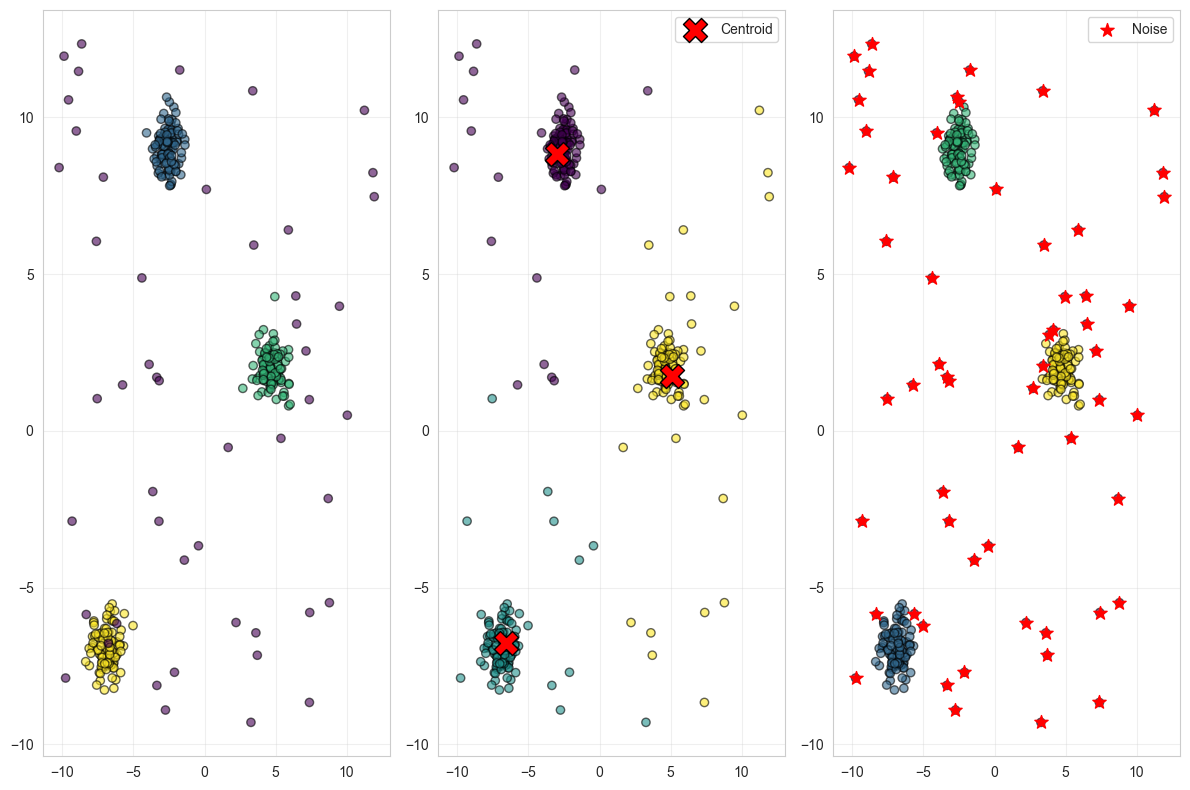

In [58]:
# Your code here
# Apply clustering algorithm and visualize results
kmeans_noisy = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans_noisy = kmeans_noisy.fit_predict(X_noisy)

dbscan_noisy = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan_noisy = dbscan_noisy.fit_predict(X_noisy)

noise_mask_noisy = labels_dbscan_noisy == -1

fig, axes = plt.subplots(1,3, figsize=(12, 8))

axes[0].scatter(X_noisy[:,0], X_noisy[:,1], c=y_noisy, alpha=0.6, cmap='viridis', edgecolors='k')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_noisy[:,0], X_noisy[:,1], c=labels_kmeans_noisy, cmap='viridis', edgecolors='k', alpha=0.6)
axes[1].scatter(kmeans_noisy.cluster_centers_[:,0], kmeans_noisy.cluster_centers_[:,1], s=300, marker='X', color='red', edgecolors='black', label='Centroid')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].scatter(X_noisy[:,0], X_noisy[:,1], c=labels_dbscan_noisy, cmap='viridis', edgecolors='k', alpha=0.6)
axes[2].scatter(X_noisy[noise_mask_noisy, 0], X_noisy[noise_mask_noisy, 1], marker='*', color='red', s=100, label='Noise')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Summary: When to Use Each Algorithm

## K-Means
✅ **Use when:**
- Clusters are spherical/globular
- Clusters are similar in size
- Number of clusters is known
- Fast computation is needed
- Data has no outliers

❌ **Avoid when:**
- Clusters have arbitrary shapes (moons, circles)
- Clusters have very different sizes or densities
- Data contains many outliers
- Number of clusters is unknown

## DBSCAN
✅ **Use when:**
- Clusters have arbitrary shapes
- Number of clusters is unknown
- Data contains outliers/noise
- Outlier detection is important
- Clusters are well-separated by density

❌ **Avoid when:**
- Clusters have very different densities
- High-dimensional data (curse of dimensionality)
- Parameters (eps, min_samples) are hard to tune
- All points must be assigned to clusters

## Key Takeaways
1. **No single algorithm is best for all data**
2. **Visualize your data** before choosing an algorithm
3. **K-Means**: Fast, simple, but assumes spherical clusters
4. **DBSCAN**: Flexible shapes, detects outliers, but sensitive to parameters
5. **Always evaluate** with metrics (silhouette score, visual inspection)
6. **Consider domain knowledge** when interpreting results

---
**End of Tutorial**